In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)

from sklearn.model_selection import train_test_split
from spectraltools import Spectral
from tensorflow import keras
from tensorflow.keras.models import save_model #saveweights
from tensorflow.keras.models import load_model

In [84]:
delimiter = ' '

# Load the file
df_spectrum = pd.read_csv('miles_stars.csv')
df_spectrum.columns = df_spectrum.iloc[0]

# Drop the first row as it's now used as header
df_spectrum = df_spectrum[1:]

# Reset the index
df_spectrum.reset_index(drop=True, inplace=True)

wavelength = df_spectrum['wav'].astype(float)
star_id = 's0050'
star_spectrum = df_spectrum[star_id].astype(float)

file_path = 'params.ascii'
df_params = pd.read_csv(file_path, delimiter=' ')
df_params.set_index('ID', inplace=True)## Data Cleaning


## Data Cleaning

In [85]:
# Remove the first and the last part of the spectrum where the instrument does not return values of intensity
df_spectrum = df_spectrum.iloc[50:len(df_spectrum.iloc[:,0])-30, :]
wavelength = df_spectrum['wav'].astype(float)

star_spectrum = df_spectrum[star_id].astype(float)
df_spectrum = df_spectrum.astype(float)
df_spectrum = df_spectrum.iloc[:,:-1]

## Normalization

In [86]:
# Normalize the columns
normalized_df =df_spectrum.div(df_spectrum.max())
df_spectrum = normalized_df

In [87]:
#remove nan and inf
nan_indices = df_params.index[df_params['__Fe_H_'].isna()]
inf_indices = df_params.index[np.isinf(df_params['__Fe_H_'])]
indices_to_drop = df_spectrum.T.index[nan_indices]
df_spectrum_metallicity = df_spectrum.T.drop(indices_to_drop).T
cleaned_data_metallicity = df_params['__Fe_H_'].replace([np.inf, -np.inf], np.nan).dropna()

max_metallicity = max(np.abs(cleaned_data_metallicity))
cleaned_data_metallicity = cleaned_data_metallicity / max_metallicity

df_spectrum_metallicity = df_spectrum_metallicity.T

X = df_spectrum_metallicity
y = cleaned_data_metallicity

# Spectral Model

In [88]:
# SPECTRAL NN MODEL

def spectral_model():
    mod = tf.keras.Sequential()
    mod.add(tf.keras.Input(shape=(x_train.shape[1])))
    mod.add(Spectral(units=200,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones',
                     diag_regularizer=tf.keras.regularizers.L2(l2=1e-2),
                     base_regularizer=tf.keras.regularizers.L2(l2=1e-4)))
    mod.add(tf.keras.layers.BatchNormalization())
    mod.add(tf.keras.layers.Dropout(0.01))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
#     mod.add(tf.keras.layers.Dropout(0.1))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
#     mod.add(tf.keras.layers.Dropout(0.1))
    mod.add(Spectral(1,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    return mod


In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
mod = spectral_model()
mod.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mae',
    metrics='mae',
)

hist = mod.fit(x_train, y_train,
               batch_size=10,
               epochs=1000,
               validation_split=0.1,
               verbose=1)

eig_start = Spectral.return_diag(mod.layers[0])
base_start = mod.layers[0].base
norma = tf.linalg.norm(base_start, ord=2, axis=1)
eig_norm = (eig_start * norma)

Epoch 1/1000
67/67 [==============================] - 3s 25ms/step - loss: 40.4045 - mae: 0.2216 - val_loss: 38.0111 - val_mae: 0.5912
Epoch 2/1000
67/67 [==============================] - 1s 22ms/step - loss: 35.1252 - mae: 0.1743 - val_loss: 32.7094 - val_mae: 0.2501
Epoch 3/1000
67/67 [==============================] - 2s 27ms/step - loss: 30.4075 - mae: 0.1645 - val_loss: 28.3447 - val_mae: 0.3343
Epoch 4/1000
67/67 [==============================] - 2s 32ms/step - loss: 26.1926 - mae: 0.1622 - val_loss: 24.1883 - val_mae: 0.1492
Epoch 5/1000
67/67 [==============================] - 2s 29ms/step - loss: 22.4268 - mae: 0.1477 - val_loss: 20.7103 - val_mae: 0.1983
Epoch 6/1000
67/67 [==============================] - 2s 31ms/step - loss: 19.1039 - mae: 0.1483 - val_loss: 17.5854 - val_mae: 0.1896
Epoch 7/1000
67/67 [==============================] - 2s 32ms/step - loss: 16.1629 - mae: 0.1359 - val_loss: 14.9156 - val_mae: 0.2575
Epoch 8/1000
67/67 [==============================] - 2

67/67 [==============================] - 1s 22ms/step - loss: 0.1004 - mae: 0.0954 - val_loss: 0.1401 - val_mae: 0.1351
Epoch 63/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0952 - mae: 0.0902 - val_loss: 0.1254 - val_mae: 0.1204
Epoch 64/1000
67/67 [==============================] - 1s 22ms/step - loss: 0.1016 - mae: 0.0967 - val_loss: 0.1492 - val_mae: 0.1442
Epoch 65/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.1050 - mae: 0.1000 - val_loss: 0.1960 - val_mae: 0.1910
Epoch 66/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0950 - mae: 0.0901 - val_loss: 0.1692 - val_mae: 0.1644
Epoch 67/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.1064 - mae: 0.1013 - val_loss: 0.1487 - val_mae: 0.1434
Epoch 68/1000
67/67 [==============================] - 2s 22ms/step - loss: 0.0988 - mae: 0.0938 - val_loss: 0.1245 - val_mae: 0.1197
Epoch 69/1000
67/67 [==============================] - 2s 23ms/step - loss: 

67/67 [==============================] - 2s 23ms/step - loss: 0.0923 - mae: 0.0869 - val_loss: 0.0962 - val_mae: 0.0910
Epoch 124/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0981 - mae: 0.0930 - val_loss: 0.1165 - val_mae: 0.1116
Epoch 125/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0957 - mae: 0.0909 - val_loss: 0.0964 - val_mae: 0.0916
Epoch 126/1000
67/67 [==============================] - 2s 24ms/step - loss: 0.0965 - mae: 0.0916 - val_loss: 0.1015 - val_mae: 0.0967
Epoch 127/1000
67/67 [==============================] - 2s 24ms/step - loss: 0.0907 - mae: 0.0860 - val_loss: 0.1028 - val_mae: 0.0981
Epoch 128/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0945 - mae: 0.0897 - val_loss: 0.0977 - val_mae: 0.0930
Epoch 129/1000
67/67 [==============================] - 1s 22ms/step - loss: 0.0924 - mae: 0.0877 - val_loss: 0.3096 - val_mae: 0.3049
Epoch 130/1000
67/67 [==============================] - 2s 24ms/step -

Epoch 184/1000
67/67 [==============================] - 2s 26ms/step - loss: 0.0940 - mae: 0.0894 - val_loss: 0.1024 - val_mae: 0.0978
Epoch 185/1000
67/67 [==============================] - 1s 22ms/step - loss: 0.0902 - mae: 0.0854 - val_loss: 0.1170 - val_mae: 0.1122
Epoch 186/1000
67/67 [==============================] - 2s 26ms/step - loss: 0.0961 - mae: 0.0911 - val_loss: 0.3789 - val_mae: 0.3734
Epoch 187/1000
67/67 [==============================] - 2s 27ms/step - loss: 0.0965 - mae: 0.0912 - val_loss: 0.1695 - val_mae: 0.1641
Epoch 188/1000
67/67 [==============================] - 2s 25ms/step - loss: 0.0942 - mae: 0.0891 - val_loss: 0.2916 - val_mae: 0.2865
Epoch 189/1000
67/67 [==============================] - 2s 22ms/step - loss: 0.0951 - mae: 0.0898 - val_loss: 0.2076 - val_mae: 0.2022
Epoch 190/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0927 - mae: 0.0876 - val_loss: 0.1560 - val_mae: 0.1511
Epoch 191/1000
67/67 [==============================] -

Epoch 245/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0915 - mae: 0.0866 - val_loss: 0.1901 - val_mae: 0.1851
Epoch 246/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0905 - mae: 0.0856 - val_loss: 0.2163 - val_mae: 0.2114
Epoch 247/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0952 - mae: 0.0903 - val_loss: 0.2084 - val_mae: 0.2036
Epoch 248/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0917 - mae: 0.0869 - val_loss: 0.1172 - val_mae: 0.1125
Epoch 249/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0889 - mae: 0.0841 - val_loss: 0.1005 - val_mae: 0.0958
Epoch 250/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0891 - mae: 0.0844 - val_loss: 0.1049 - val_mae: 0.1002
Epoch 251/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0902 - mae: 0.0855 - val_loss: 0.1100 - val_mae: 0.1053
Epoch 252/1000
67/67 [==============================] -

...

Epoch 733/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0880 - mae: 0.0835 - val_loss: 0.1023 - val_mae: 0.0978
Epoch 734/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0913 - mae: 0.0868 - val_loss: 0.1674 - val_mae: 0.1628
Epoch 735/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0876 - mae: 0.0831 - val_loss: 0.1346 - val_mae: 0.1302
Epoch 736/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0858 - mae: 0.0814 - val_loss: 0.1222 - val_mae: 0.1178
Epoch 737/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0916 - mae: 0.0870 - val_loss: 0.1037 - val_mae: 0.0991
Epoch 738/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0853 - mae: 0.0808 - val_loss: 0.1199 - val_mae: 0.1154
Epoch 739/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0827 - mae: 0.0782 - val_loss: 0.1283 - val_mae: 0.1238
Epoch 740/1000
67/67 [==============================] -

Epoch 794/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0919 - mae: 0.0871 - val_loss: 0.1155 - val_mae: 0.1108
Epoch 795/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0865 - mae: 0.0819 - val_loss: 0.1306 - val_mae: 0.1261
Epoch 796/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0862 - mae: 0.0816 - val_loss: 0.1155 - val_mae: 0.1108
Epoch 797/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0857 - mae: 0.0812 - val_loss: 0.1134 - val_mae: 0.1089
Epoch 798/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0825 - mae: 0.0780 - val_loss: 0.1795 - val_mae: 0.1750
Epoch 799/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0852 - mae: 0.0807 - val_loss: 0.1594 - val_mae: 0.1549
Epoch 800/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0854 - mae: 0.0808 - val_loss: 0.1136 - val_mae: 0.1091
Epoch 801/1000
67/67 [==============================] -

Epoch 855/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0864 - mae: 0.0821 - val_loss: 0.1587 - val_mae: 0.1543
Epoch 856/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0854 - mae: 0.0810 - val_loss: 0.1291 - val_mae: 0.1247
Epoch 857/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0865 - mae: 0.0821 - val_loss: 0.1099 - val_mae: 0.1056
Epoch 858/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0852 - mae: 0.0809 - val_loss: 0.1220 - val_mae: 0.1178
Epoch 859/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0863 - mae: 0.0820 - val_loss: 0.1072 - val_mae: 0.1029
Epoch 860/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0856 - mae: 0.0812 - val_loss: 0.1154 - val_mae: 0.1112
Epoch 861/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0891 - mae: 0.0849 - val_loss: 0.1557 - val_mae: 0.1513
Epoch 862/1000
67/67 [==============================] -

Epoch 916/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0837 - mae: 0.0793 - val_loss: 0.1597 - val_mae: 0.1552
Epoch 917/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0911 - mae: 0.0865 - val_loss: 0.1277 - val_mae: 0.1229
Epoch 918/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0922 - mae: 0.0877 - val_loss: 0.1339 - val_mae: 0.1293
Epoch 919/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0878 - mae: 0.0834 - val_loss: 0.1741 - val_mae: 0.1694
Epoch 920/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0839 - mae: 0.0793 - val_loss: 0.1176 - val_mae: 0.1132
Epoch 921/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0868 - mae: 0.0823 - val_loss: 0.0930 - val_mae: 0.0887
Epoch 922/1000
67/67 [==============================] - 2s 23ms/step - loss: 0.0842 - mae: 0.0797 - val_loss: 0.1572 - val_mae: 0.1527
Epoch 923/1000
67/67 [==============================] -

Epoch 977/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0819 - mae: 0.0773 - val_loss: 0.2201 - val_mae: 0.2154
Epoch 978/1000
67/67 [==============================] - 1s 20ms/step - loss: 0.0875 - mae: 0.0829 - val_loss: 0.1003 - val_mae: 0.0958
Epoch 979/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0845 - mae: 0.0800 - val_loss: 0.0974 - val_mae: 0.0930
Epoch 980/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0874 - mae: 0.0830 - val_loss: 0.1031 - val_mae: 0.0987
Epoch 981/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0833 - mae: 0.0789 - val_loss: 0.1223 - val_mae: 0.1179
Epoch 982/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0857 - mae: 0.0813 - val_loss: 0.1249 - val_mae: 0.1205
Epoch 983/1000
67/67 [==============================] - 1s 21ms/step - loss: 0.0876 - mae: 0.0831 - val_loss: 0.0995 - val_mae: 0.0951
Epoch 984/1000
67/67 [==============================] -

Eigenvalues distribution

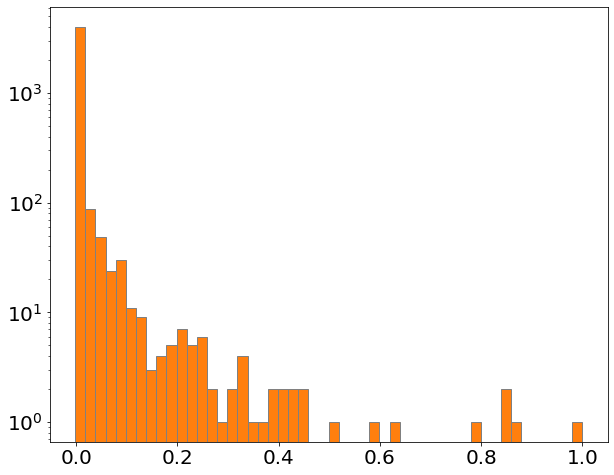

In [17]:
plt.figure(figsize=(10,8))
plt.hist(lambda_mean/np.max(lambda_mean), 50, facecolor='tab:orange', ec = 'grey')
plt.yscale('log')
plt.show()

Loss Vs number of spectral lines used as input of the model

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


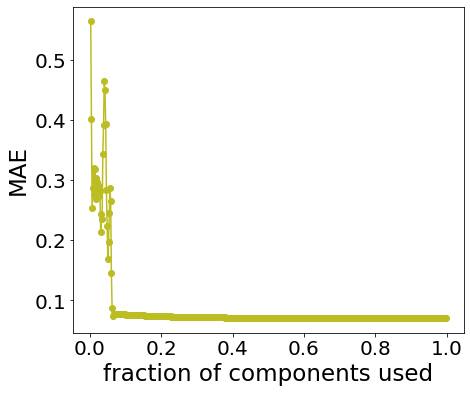

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_prune = []
mse_prune = []

eig_norm = eig_norm.numpy()

max_features = 500 

for n in range(1,max_features):
    mask = eig_norm.copy()
    th = np.sort(np.abs(eig_norm))[-n]
    mask[np.abs(mask)<th]=0
    mask[np.abs(mask)>=th]=1
    y_pred = mod.predict(x_test*mask, verbose=0)
    
    mae_prune.append(mean_absolute_error(y_test, y_pred))
    mse_prune.append(mean_squared_error(y_test, y_pred)) 

xM = 200
vl = 31
plt.figure(figsize=(7,6))
plt.plot(np.arange(1, max_features)[:xM]/len(eig_norm), mae_prune[:xM], color='tab:olive',marker='o')
plt.xlabel('fraction of components used', fontsize=23)
plt.ylabel('MAE', fontsize=23)
plt.show()


An example of stellar spectra comparaed with the network eigenvalues

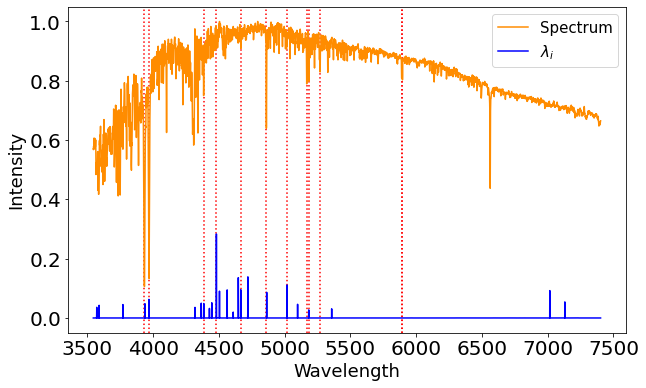

In [38]:
star_id = 's0050'
star_spectrum = df_spectrum[star_id].astype(float)

plt.figure(figsize=(10,6))

plt.axvline(3934, ls ='dotted', color = 'r')  # CaII H
plt.axvline(3968, ls ='dotted', color = 'r')  # K
plt.axvline(5173, ls ='dotted', color = 'r')  # Mg_1
plt.axvline(5184, ls ='dotted', color = 'r')  # Mg_2
plt.axvline(5270, ls ='dotted', color = 'r')  # Fe_1
plt.axvline(5896, ls ='dotted', color = 'r')  # Na_D_1
plt.axvline(5890, ls ='dotted', color = 'r')  # Na_D_2
plt.axvline(4667, ls ='dotted', color = 'r')  # FeIII(?)
plt.axvline(5018, ls ='dotted', color = 'r')  # FeII(?)
plt.axvline(4384, ls ='dotted', color = 'r')  # FeI
plt.axvline(4481, ls ='dotted', color = 'r')  # MaII(?)
plt.axvline(4861, ls ='dotted', color = 'r')  # Balmer_7

plt.plot(wavelength, star_spectrum, 'darkorange', label = 'Spectrum')
plt.plot(wavelength, np.abs(eig_norm), 'b', label = '$\lambda_i$')
plt.legend(fontsize = 15)
plt.xlabel('Wavelength', fontsize='18')
plt.ylabel('Intensity', fontsize='18')
plt.show()